In [5]:
%load_ext autoreload
%autoreload 2

# Get parent directory and add to sys.path
import sys, os
parent_dir = os.path.dirname(os.getcwd())
sys.path.append(parent_dir)

# Require ipympl
%matplotlib widget 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
import time
from LandMPC_part_6.MPCLandControl import MPCLandControl
from src.rocket import Rocket, perturb_rocket
from src.pos_rocket_vis import *

rocket_obj_path = os.path.join(parent_dir, "Cartoon_rocket.obj")
rocket_params_path = os.path.join(parent_dir,"rocket.yaml")

# Rocket setup
Ts  = 1/20
rocket = Rocket(Ts=Ts, model_params_filepath=rocket_params_path)
rocket.mass = 1.7 # Do not change!!!

# Visualization setup
vis = RocketVis(rocket, rocket_obj_path)
vis.anim_rate = 1

Linearization around a steady state:
x_ref =  [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 3.]
xs =  [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 3.]
us =  [ 0.          0.         56.66666667  0.        ]


Task was destroyed but it is pending!
task: <Task pending name='Task-75' coro=<_async_in_context.<locals>.run_in_context() running at c:\Users\Aayushi Barve\.conda\envs\mpc2025bis\Lib\site-packages\ipykernel\utils.py:60> wait_for=<Task pending name='Task-2' coro=<Kernel.shell_main() running at c:\Users\Aayushi Barve\.conda\envs\mpc2025bis\Lib\site-packages\ipykernel\kernelbase.py:590> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at c:\Users\Aayushi Barve\.conda\envs\mpc2025bis\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
<frozen abc>:123: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
Task was destroyed but it is pending!
task: <Task pending name='Task-2' coro=<Kernel.shell_main() running at c:\Users\Aayushi Barve\.conda\envs\mpc2025bis\Lib\site-packages\ipykernel\kernelbase.py:590> cb=[Task.task_wakeup()]>


Eigenvalues of closed loop state matrix= [0.89716223 0.9452143 ]
Vertices of the input constraint U= [[40.]
 [80.]]
Vertices of the tightened input constraint U_tilde= [[45.8185985 ]
 [62.90350418]]


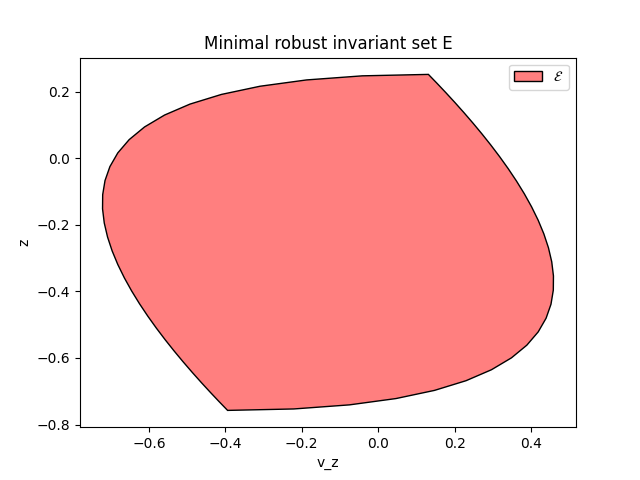

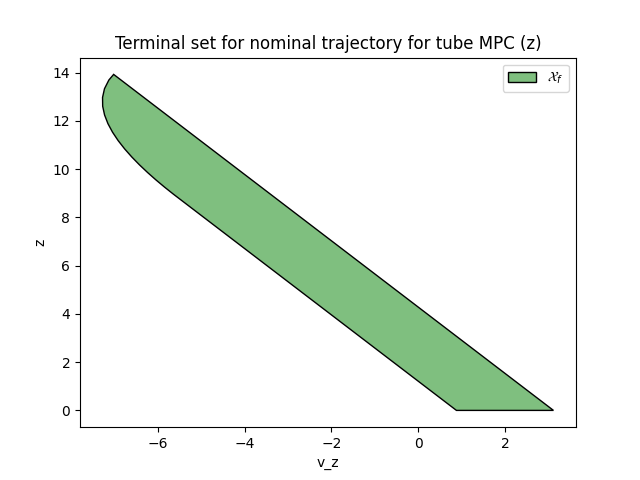

In [7]:
sim_time = 8 # simulation length in seconds
x0=np.array([0.,0.,0.,0.,0.,np.deg2rad(30),0.,0.,0.,3.,2.,10.]) # w, phi, v, p
x_ref = np.array([0.,0.,0.,0.,0.,0.,0.,0.,0.,1.,0.,3.])
xs, us = rocket.trim(x_ref)
print("Linearization around a steady state:")
print("x_ref = ", x_ref)
print("xs = ", xs)
print("us = ", us)
A, B = rocket.linearize(xs, us)

# MPC parameters
H = 5.0
# Merge four linear mpc
mpc = MPCLandControl().new_controller(rocket, Ts, H, x_ref=x_ref)

Simulating time 0.00

 State alpha violation: 0.18 > 0.17, 
 State alpha violation: 0.18 > 0.17, 
 State alpha violation: 0.17 > 0.17, Simulating time 1.00
Simulating time 2.00
Simulating time 3.00
Simulating time 4.00
Simulating time 5.00
Simulating time 6.00
Simulating time 7.00


AppLayout(children=(HBox(children=(Play(value=0, description='Press play', max=159, step=2), IntSlider(value=0…

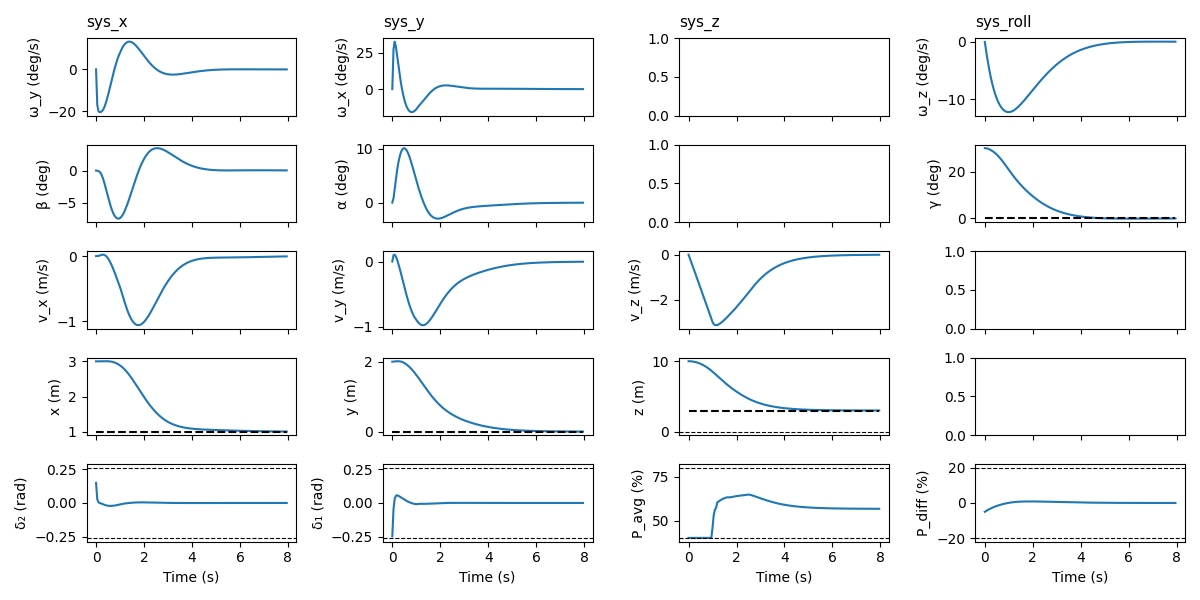

In [8]:
t_cl, x_cl, u_cl, t_ol, x_ol, u_ol = rocket.simulate_land(mpc, sim_time, H, x0)
vis.animate(t_cl[:-1], x_cl[:,:-1], u_cl, T_ol=t_ol[...,:-1], X_ol=x_ol, U_ol=u_ol)
plot_static_states_inputs(t_cl[:-1], x_cl[:,:-1], u_cl, xs)